# Processing Sentinel-2 Images spatial resolution 10m

In [ ]:
# load the required libaries
!pip install rasterio numpy
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

In [ ]:
# defining all the band
red_band = '20191003T045659_20191003T050942_T44PKT.B4.tif'
green_band = '20191003T045659_20191003T050942_T44PKT.B3.tif'
blue_band = '20191003T045659_20191003T050942_T44PKT.B2.tif'
nir_band = '20191003T045659_20191003T050942_T44PKT.B8.tif'
swir_band = '20210125T050059_20210125T050922_T44PLS.B11.tif'

## Review the Image in RGB

In [ ]:
# B2 = Blue
# B3 = Green
# B4 = Red

# reading the Red Green Blue Bands
with rasterio.open('20191003T045659_20191003T050942_T44PKT.B4.tif') as red_src:
    red = red_src.read(1)

with rasterio.open('20191003T045659_20191003T050942_T44PKT.B3.tif') as green_src:
    green = green_src.read(1)

with rasterio.open('20191003T045659_20191003T050942_T44PKT.B2.tif') as blue_src:
    blue = blue_src.read(1)

In [ ]:
# creating RGB array
rgb = np.dstack([red, green, blue])

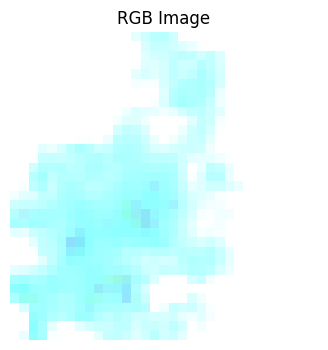

In [ ]:
# visualization
plt.figure(figsize=(6, 4))
plt.imshow(rgb)
plt.title('RGB Image')
plt.axis("off")
plt.show()

Got range [130..3818] for RGB Image thus we need to normalize

In [ ]:
# normalize the array
def normalize(arr):
    arr_min, arr_max = arr.min(), arr.max()
    return ((arr - arr_min) / (arr_max - arr_min) * 255).astype('uint8')

rgb_normalized = np.dstack([
    normalize(red),
    normalize(green),
    normalize(blue)
])

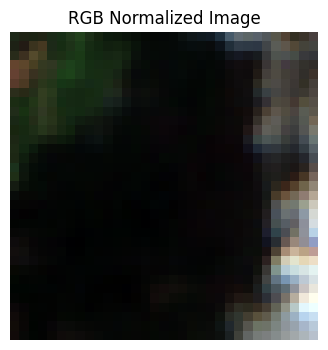

In [ ]:
# visualization
plt.figure(figsize=(6, 4))
plt.imshow(rgb_normalized)
plt.title('RGB Normalized Image')
plt.axis("off")
plt.show()

## Vegetation Indice - Normalized Difference Vegetation Index (NDVI)

Band 4 : Red band  
* Wavelength 665 nm
* spatial resolution 10m


Band 8 : Near-Infrared
* Wavelength around 842 nm
* Higher spatial resolution 10m


Band 8A : Near-Infrared
* Wavelength around 865 nm
* spatial resolution 20m

#### NDVI using Band 8

In [ ]:
# load the files required for NDVI calculation
with rasterio.open('20191003T045659_20191003T050942_T44PKT.B4.tif') as red_src:
    red = red_src.read(1).astype(float)

with rasterio.open('20191003T045659_20191003T050942_T44PKT.B8.tif') as nir_src:
    nir = nir_src.read(1).astype(float)

In [ ]:
# calculation for NDVI
# NDVI array
ndvi = (nir - red) / (nir + red)

# Legal NDVI range is -1 to 1, invalid values NaN bana do
ndvi = np.where((ndvi >= -1) & (ndvi <= 1), ndvi, np.nan)

In [ ]:
type(ndvi)

numpy.ndarray

In [ ]:
ndvi.shape

(33, 33)

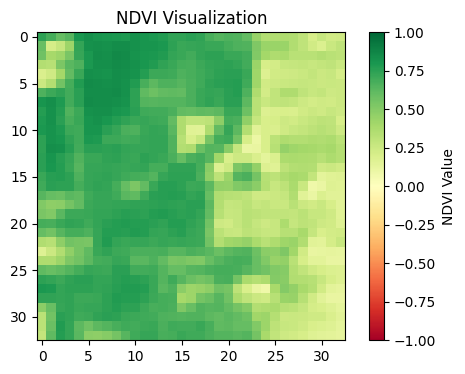

In [ ]:
# visualization for NDVI array
plt.figure(figsize=(6, 4))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI Value')
plt.title('NDVI Visualization')
plt.show()

In [ ]:
# statastical summary of NDVI
ndvi_mean = np.nanmean(ndvi)
ndvi_max = np.nanmax(ndvi)
ndvi_min = np.nanmin(ndvi)
ndvi_std = np.nanstd(ndvi)

print(f"Mean NDVI: {ndvi_mean}")
print(f"Max NDVI: {ndvi_max}")
print(f"Min NDVI: {ndvi_min}")
print(f"Std Deviation NDVI: {ndvi_std}")

Mean NDVI: 0.5447462092291131
Max NDVI: 0.855379188712522
Min NDVI: 0.07885714285714286
Std Deviation NDVI: 0.2158280756979


#### NDVI using Band 8A

In [ ]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling

# load the files required for NDVI calculation
with rasterio.open('20191003T045659_20191003T050942_T44PKT.B4.tif') as red_src:
    red = red_src.read(1).astype(float)
    red_transform = red_src.transform
    red_crs = red_src.crs
    red_shape = red_src.shape

with rasterio.open('20191003T045659_20191003T050942_T44PKT.B8A.tif') as nir_src:
    # Read the NIR band
    nir_data = nir_src.read(1).astype(float)

    # Initialize an empty array for the resampled NIR data, matching the red band's shape
    nir_resampled = np.empty(red_shape, dtype=float)

    # Reproject the NIR band to match the red band's transform and shape
    reproject(
        source=nir_data,
        destination=nir_resampled,
        src_transform=nir_src.transform,
        src_crs=nir_src.crs,
        dst_transform=red_transform,
        dst_crs=red_crs,
        resampling=Resampling.nearest # Using nearest neighbor for simplicity, can be changed to bilinear or cubic
    )
    nir = nir_resampled

In [ ]:
# calculation for NDVI
# NDVI array
ndvi = (nir - red) / (nir + red)

# Legal NDVI range is -1 to 1, invalid values NaN bana do
ndvi = np.where((ndvi >= -1) & (ndvi <= 1), ndvi, np.nan)

In [ ]:
type(ndvi)

numpy.ndarray

In [ ]:
ndvi.shape

(33, 33)

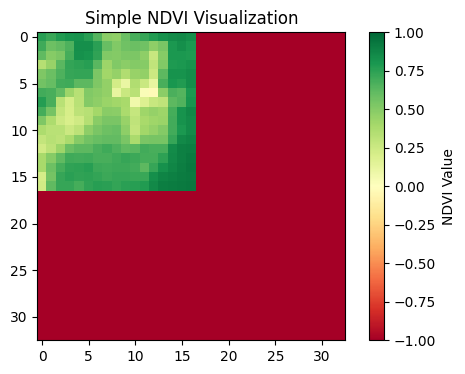

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate NDVI
sum_bands = nir + red
ndvi = np.where(sum_bands == 0, np.nan, (nir - red) / sum_bands)

# Ensure NDVI is within the valid range [-1, 1]
ndvi = np.clip(ndvi, -1, 1)

# Visualize NDVI
plt.figure(figsize=(6, 4))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI Value')
plt.title('Simple NDVI Visualization')
plt.show()

In [ ]:
# statastical summary of NDVI
ndvi_mean = np.nanmean(ndvi)
ndvi_max = np.nanmax(ndvi)
ndvi_min = np.nanmin(ndvi)
ndvi_std = np.nanstd(ndvi)

print(f"Mean NDVI: {ndvi_mean}")
print(f"Max NDVI: {ndvi_max}")
print(f"Min NDVI: {ndvi_min}")
print(f"Std Deviation NDVI: {ndvi_std}")

Mean NDVI: -0.5777008987486673
Max NDVI: 0.9238692342140618
Min NDVI: -1.0
Std Deviation NDVI: 0.7101674830806526


## Vegetation Indice - Normalized Difference Water Index (NDWI)


 * Band 8 (NIR, 10m resolution) - (33,33)
 * Band 11 (SWIR, 20m resolution) - (17,17)

In [ ]:
# read images
# NIR Band
with rasterio.open(nir_band) as nir_src:
    nir = nir_src.read(1)
    nir_profile = nir_src.profile

# SWIR Band
with rasterio.open(swir_band) as swir_src:
    swir = swir_src.read(1)
    swir_profile = swir_src.profile

In [ ]:
# resampling SWIR band 20m → 10m

# desired SWIR band shape and resolution
resampled_swir = np.empty(nir.shape, dtype=swir.dtype)

reproject(
    source=swir,
    destination=resampled_swir,
    src_transform=swir_src.transform,
    src_crs=swir_src.crs,
    dst_transform=nir_src.transform,
    dst_crs=nir_src.crs,
    resampling=Resampling.bilinear # or nearest
)


(array([[4582, 4811, 4837, ...,    0,    0,    0],
        [4633, 4760, 4893, ...,    0,    0,    0],
        [3708, 4094, 4665, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0]], dtype=uint16),
 Affine(1.0, 0.0, 0.0,
        0.0, -1.0, 0.0))

In [ ]:
# NWDI calculation
ndwi = (nir - resampled_swir) / (nir + resampled_swir)
ndwi = np.where((nir + resampled_swir) == 0, 0, ndwi) # avoid division by zero

In [ ]:
ndwi.shape

(33, 33)

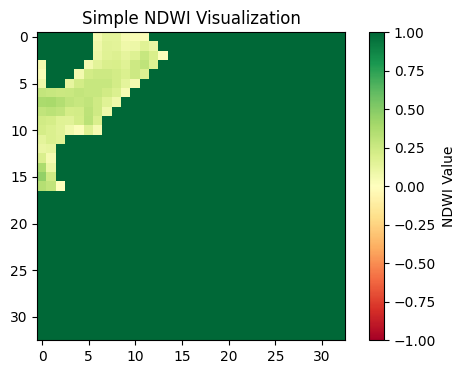

In [ ]:
# Visualize NDWI
plt.figure(figsize=(6, 4))
plt.imshow(ndwi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDWI Value')
plt.title('Simple NDWI Visualization')
plt.show()

In [ ]:
# statastical summary of NWDI
ndwi_mean = np.nanmean(ndwi)
ndwi_max = np.nanmax(ndwi)
ndwi_min = np.nanmin(ndwi)
ndwi_std = np.nanstd(ndwi)

print(f"Mean ndwi: {ndwi_mean}")
print(f"Max ndwi: {ndwi_max}")
print(f"Min ndwi: {ndwi_min}")
print(f"Std Deviation ndwi: {ndwi_std}")

Mean ndwi: 3.351883775867054
Max ndwi: 23.85650723025584
Min ndwi: 0.0026305900037579856
Std Deviation ndwi: 5.653031026493737


##  Enhanced Vegetation Index (EVI)

In [ ]:
# read the bands
with rasterio.open(nir_band) as nir_src:
    nir = nir_src.read(1).astype(float)

with rasterio.open(red_band) as red_src:
    red = red_src.read(1).astype(float)

with rasterio.open(blue_band) as blue_src:
    blue = blue_src.read(1).astype(float)

In [ ]:
# Calculate EVI
G = 2.5
C1 = 6.0
C2 = 7.5
L = 1.0

numerator = nir - red
denominator = nir + C1 * red - C2 * blue + L

# Initialize evi array with zeros
evi = np.zeros_like(denominator, dtype=float)

# Create a boolean mask for non-zero denominators
valid_denominator_mask = denominator != 0

# Perform the calculation only for valid denominators to avoid division by zero warning
evi[valid_denominator_mask] = G * (numerator[valid_denominator_mask] / denominator[valid_denominator_mask])

In [ ]:
type(evi)

numpy.ndarray

In [ ]:
evi.shape

(33, 33)

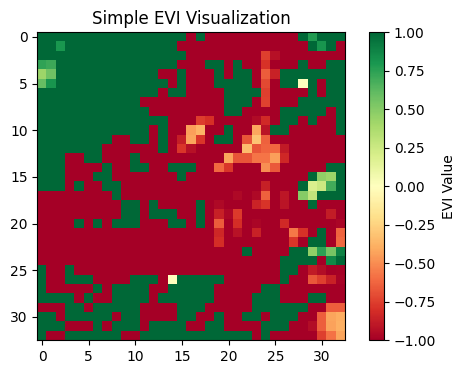

In [ ]:
# Visualize EVI
plt.figure(figsize=(6, 4))
plt.imshow(evi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='EVI Value')
plt.title('Simple EVI Visualization')
plt.show()

In [ ]:
# statastical summary of EVI
evi_mean = np.nanmean(evi)
evi_max = np.nanmax(evi)
evi_min = np.nanmin(evi)
evi_std = np.nanstd(evi)

print(f"Mean evi: {evi_mean}")
print(f"Max evi: {evi_max}")
print(f"Min evi: {evi_min}")
print(f"Std Deviation evi: {evi_std}")

Mean evi: -1.322436633168261
Max evi: 4730.0
Min evi: -2392.5
Std Deviation evi: 203.30449282979941


## Atmospherically Resistant Vegetation Index (ARVI)

In [ ]:
# Read bands
with rasterio.open(nir_band) as nir_src:
    nir = nir_src.read(1).astype(float)

with rasterio.open(red_band) as red_src:
    red = red_src.read(1).astype(float)

with rasterio.open(blue_band) as blue_src:
    blue = blue_src.read(1).astype(float)

In [ ]:
gamma = 1.0

# ARVI calculation
red_corr = red - gamma * (blue - red)
arvi = (nir - red_corr) / (nir + red_corr)

# Handle division by zero or invalid values
arvi = np.where((nir + red_corr) == 0, 0, arvi)

In [ ]:
arvi.shape

(33, 33)

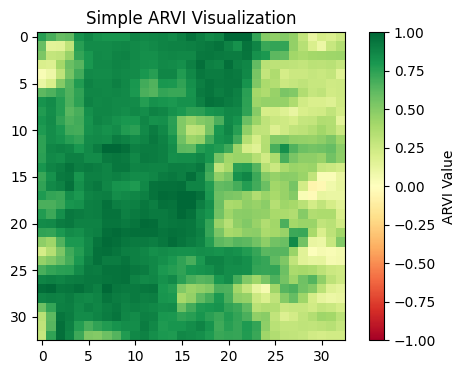

In [ ]:
# Visualize ARVI
plt.figure(figsize=(6, 4))
plt.imshow(arvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='ARVI Value')
plt.title('Simple ARVI Visualization')
plt.show()

In [ ]:
# statastical summary of ARVI
arvi_mean = np.nanmean(arvi)
arvi_max = np.nanmax(arvi)
arvi_min = np.nanmin(arvi)
arvi_std = np.nanstd(arvi)

print(f"Mean arvi: {arvi_mean}")
print(f"Max arvi: {arvi_max}")
print(f"Min arvi: {arvi_min}")
print(f"Std Deviation arvi: {arvi_std}")

Mean arvi: 0.6644992148834399
Max arvi: 1.0210304942166142
Min arvi: -0.06992417860151642
Std Deviation arvi: 0.2588149516713055


## Green Chlorophyll Index (GCI)

In [ ]:
# Read Green band (Band 3)
with rasterio.open(green_band) as green_src:
    green = green_src.read(1).astype(float)

# Read NIR band (Band 8)
with rasterio.open(nir_band) as nir_src:
    nir = nir_src.read(1).astype(float)

In [ ]:
# Calculate GCI
gci = (nir / green) - 1

# Handle division by zero or invalid values
gci = np.where(green == 0, 0, gci)

In [ ]:
gci.shape

(33, 33)

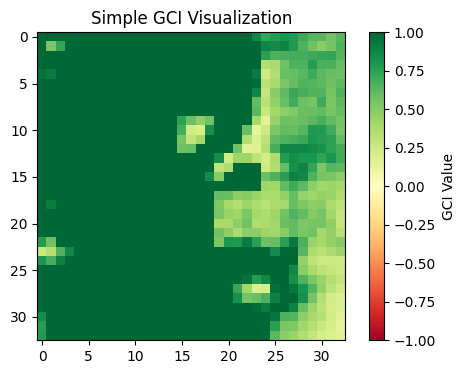

In [ ]:
# Visualize GCI
plt.figure(figsize=(6, 4))
plt.imshow(gci, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='GCI Value')
plt.title('Simple GCI Visualization')
plt.show()

In [ ]:
# statastical summary of ARVI
gci_mean = np.nanmean(gci)
gci_max = np.nanmax(gci)
gci_min = np.nanmin(gci)
gci_std = np.nanstd(gci)

print(f"Mean gci: {gci_mean}")
print(f"Max gci: {gci_max}")
print(f"Min gci: {gci_min}")
print(f"Std Deviation gci: {gci_std}")

Mean gci: 1.8871273220405194
Max gci: 5.337349397590361
Min gci: 0.13913043478260878
Std Deviation gci: 1.2168146560070618


## Moisture Stress Index (MSI)

In [ ]:
with rasterio.open(swir_band) as swir_src:
    swir = swir_src.read(1).astype(float)

with rasterio.open(nir_band) as nir_src:
    nir = nir_src.read(1).astype(float)

In [ ]:
# desired SWIR band shape and resolution
resampled_swir = np.empty(nir.shape, dtype=swir.dtype)

reproject(
    source=swir,
    destination=resampled_swir,
    src_transform=swir_src.transform,
    src_crs=swir_src.crs,
    dst_transform=nir_src.transform,
    dst_crs=nir_src.crs,
    resampling=Resampling.bilinear # or nearest
)

(array([[4582., 4811., 4837., ...,    0.,    0.,    0.],
        [4633., 4760., 4893., ...,    0.,    0.,    0.],
        [3708., 4094., 4665., ...,    0.,    0.,    0.],
        ...,
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.],
        [   0.,    0.,    0., ...,    0.,    0.,    0.]]),
 Affine(1.0, 0.0, 0.0,
        0.0, -1.0, 0.0))

In [ ]:
# calculation
msi = resampled_swir / nir

# Handle division by zero or invalid values
msi = np.where(nir == 0, 0, msi)

In [ ]:
msi.shape

(33, 33)

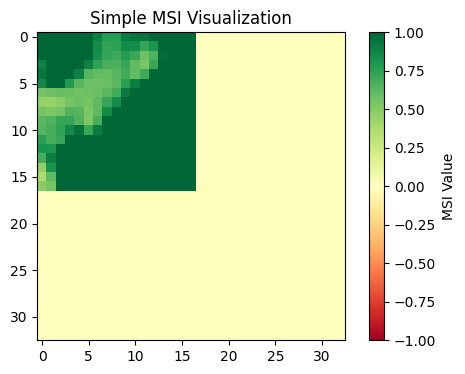

In [ ]:
# Visualize MSI
plt.figure(figsize=(6, 4))
plt.imshow(msi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='MSI Value')
plt.title('Simple MSI Visualization')
plt.show()

In [ ]:
# statastical summary of MSI
msi_mean = np.nanmean(msi)
msi_max = np.nanmax(msi)
msi_min = np.nanmin(msi)
msi_std = np.nanstd(msi)

print(f"Mean msi: {msi_mean}")
print(f"Max msi: {msi_max}")
print(f"Min msi: {msi_min}")
print(f"Std Deviation msi: {msi_std}")

Mean msi: 0.4501333485804988
Max msi: 7.3565891472868215
Min msi: 0.0
Std Deviation msi: 0.9365858553349219


## Visualize all the Parameters

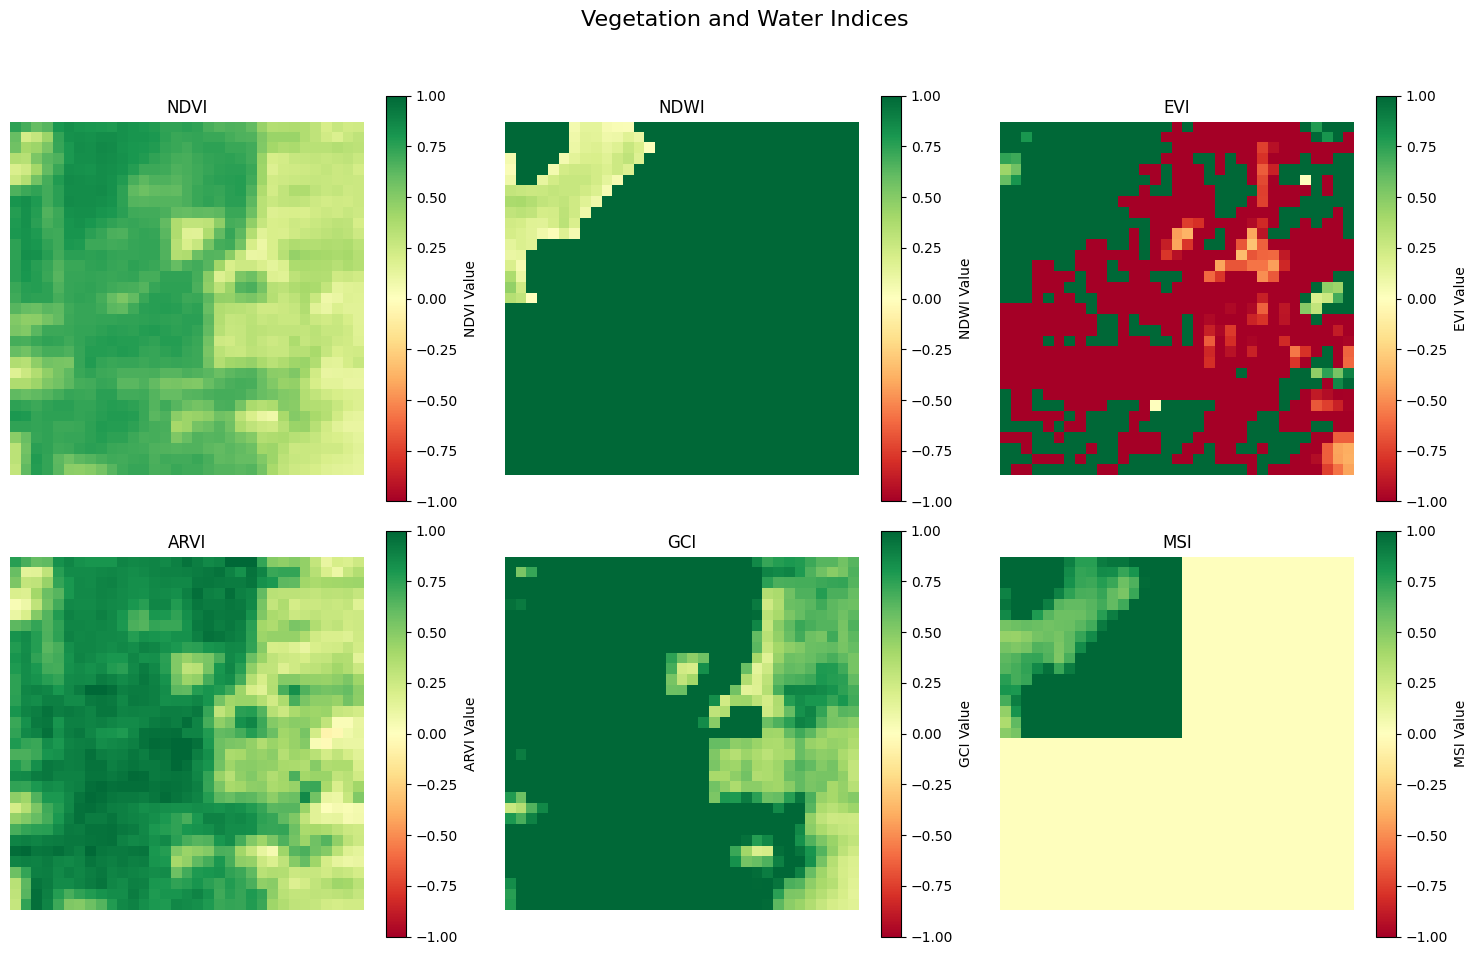

In [ ]:
# Visualize all the Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Vegetation and Water Indices', fontsize=16)

axes = axes.flatten()

indices = [ndvi, ndwi, evi, arvi, gci, msi]
titles = ['NDVI', 'NDWI', 'EVI', 'ARVI', 'GCI', 'MSI']

for i, (index_data, title) in enumerate(zip(indices, titles)):
    ax = axes[i]
    im = ax.imshow(index_data, cmap='RdYlGn', vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(im, ax=ax, label=f'{title} Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
DATE: 1/12/2025

In [ ]:
import rasterio

path = "/content/20191003T045659_20191003T050942_T44PKT.B4.tif"

with rasterio.open(path) as src:
    band4 = src.read(1)   # read first band
    print(band4.shape)
    print(src.crs)        # coordinate system
    print(src.transform)  # geotransform


(33, 33)
EPSG:32644
| 1.00, 0.00, 0.00|
| 0.00,-1.00, 0.00|
| 0.00, 0.00, 1.00|


In [ ]:
import rasterio

path = "/content/20191003T045659_20191003T050942_T44PKT.B3.tif"

with rasterio.open(path) as src:
    band4 = src.read(1)   # read first band
    print(band4.shape)
    print(src.crs)        # coordinate system
    print(src.transform)  # geotransform

(33, 33)
EPSG:32644
| 1.00, 0.00, 0.00|
| 0.00,-1.00, 0.00|
| 0.00, 0.00, 1.00|


In [ ]:
import rasterio

path = "/content/20191003T045659_20191003T050942_T44PKT.B2.tif"

with rasterio.open(path) as src:
    band4 = src.read(1)   # read first band
    print(band4.shape)
    print(src.crs)        # coordinate system
    print(src.transform)  # geotransform

(33, 33)
EPSG:32644
| 1.00, 0.00, 0.00|
| 0.00,-1.00, 0.00|
| 0.00, 0.00, 1.00|


In [ ]:
import rasterio
import glob

folder = "/content"   # change this
band_files = sorted(glob.glob(folder + "*.tif"))

bands = {}

for bf in band_files:
    name = bf.split("/")[-1].split(".")[0]    # gets file name without .tif
    with rasterio.open(bf) as src:
        bands[name] = src.read(1)

print(bands.keys())     # all loaded bands
#print(bands['B4'].shape)


dict_keys([])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

R = bands['B4']
G = bands['B3']
B = bands['B2']

rgb = np.dstack((R, G, B))
rgb = rgb / rgb.max()

plt.imshow(rgb)
plt.title("Sentinel-2 RGB Image")
plt.axis('off')
plt.show()


In [ ]:
import requests

# Zenodo download link for the SICKLE dataset
url = "https://zenodo.org/records/10393972/files/SICKLE.zip?download=1"

output = "SICKLE.zip"

print("Downloading SICKLE dataset...")
r = requests.get(url)

with open(output, "wb") as f:
    f.write(r.content)

print("Download complete! Saved as SICKLE.zip")

Download complete! Saved as SICKLE.zip


In [ ]:
import requests

url = "https://zenodo.org/record/10393972/files/SICKLE.zip"
output = "SICKLE.zip"

print("Downloading SICKLE dataset (this may take time)...")

response = requests.get(url, stream=True)
response.raise_for_status()

with open(output, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print("Download complete!")

HTTPError: 404 Client Error: NOT FOUND for url: https://zenodo.org/records/10393972/files/SICKLE.zip?download=1

In [ ]:
import zipfile

zip_path = "SICKLE.zip"

if zipfile.is_zipfile(zip_path):
    print("ZIP file is valid")
else:
    print("Corrupted ZIP file!")


Corrupted ZIP file!


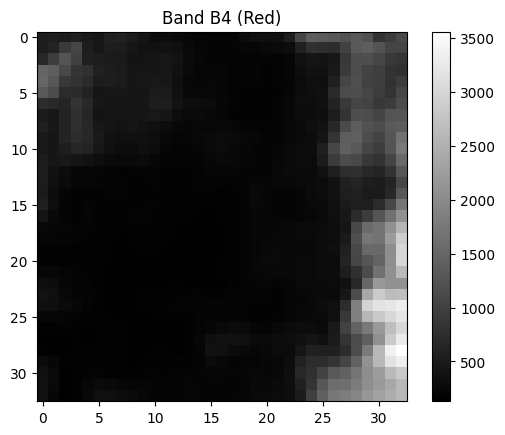

In [ ]:
import rasterio
import matplotlib.pyplot as plt

path = "/content/20191003T045659_20191003T050942_T44PKT.B4.tif"   # Red band

with rasterio.open(path) as src:
    img = src.read(1)

plt.imshow(img, cmap="gray")
plt.title("Band B4 (Red)")
plt.colorbar()
plt.show()


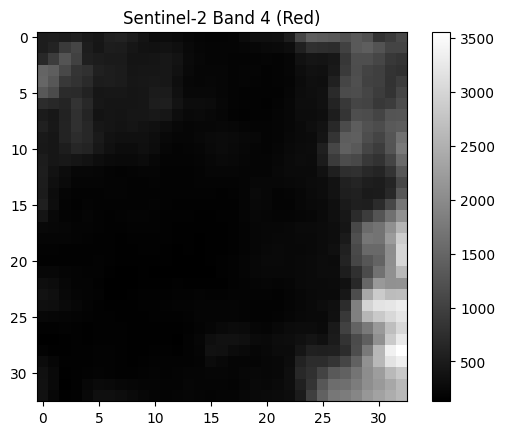

In [ ]:
import rasterio
import matplotlib.pyplot as plt

path = "/content/20191003T045659_20191003T050942_T44PKT.B4.tif"  # red band

with rasterio.open(path) as src:
    red = src.read(1)

plt.imshow(red, cmap='gray')
plt.title("Sentinel-2 Band 4 (Red)")
plt.colorbar()
plt.show()


In [ ]:
import numpy as np

bands = []
for b in ["B4","B3","B2"]:
    with rasterio.open(f"SICKLE_DATA/S2/sample_001/{b}.tif") as src:
        bands.append(src.read(1))

rgb = np.dstack(bands)
rgb = rgb / np.max(rgb)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Sentinel-2 True Color (RGB)")
plt.axis("off")
plt.show()


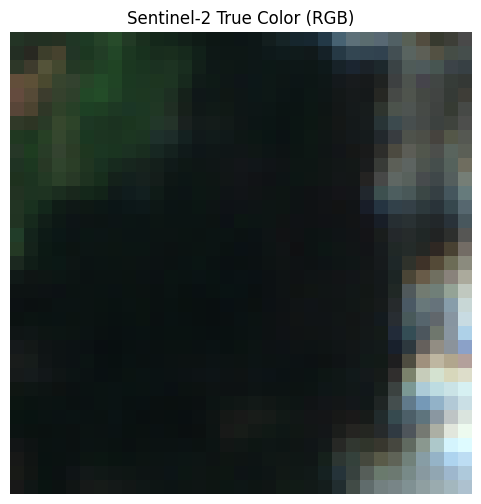

In [ ]:
import numpy as np
import matplotlib.pyplot as plt # Added import for matplotlib

bands = []
B4="/content/20191003T045659_20191003T050942_T44PKT.B4.tif"
B3="/content/20191003T045659_20191003T050942_T44PKT.B3.tif"
B2="/content/20191003T045659_20191003T050942_T44PKT.B2.tif"
for band_path in [B4, B3, B2]: # Corrected to iterate over file paths
    with rasterio.open(band_path) as src:
        bands.append(src.read(1))

rgb = np.dstack(bands)
rgb = rgb / np.max(rgb)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Sentinel-2 True Color (RGB)")
plt.axis("off")
plt.show()


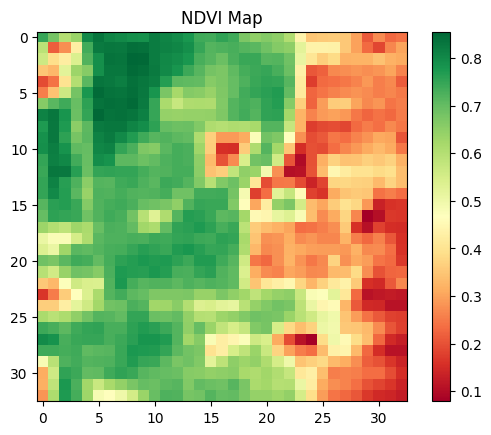

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/content/20191003T045659_20191003T050942_T44PKT.B8.tif") as s:
    B8 = s.read(1)
with rasterio.open("/content/20191003T045659_20191003T050942_T44PKT.B4.tif") as s:
    B4 = s.read(1)

ndvi = (B8 - B4) / (B8 + B4 + 1e-6)

plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar()
plt.title("NDVI Map")
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv("/content/sickle_dataset_tabular.csv")
df.head()


,UNIQUE_ID,PLOT_ID,RIVER_PART,STANDARD_SEASON,YEAR,AREA,CROP,VARIETY,PADDY_BIN,SOWING_DATE,TRANSPLANTING_DATE,HARVESTING_DATE,SOWING_DAY,TRANSPLANTING_DAY,HARVESTING_DAY,YIELD,SPLIT
0,2315,417.0,NaN,oct-mar,2020.0,1.00,Paddy,Kalser,1.0,10/3/2020,11/3/2020,2/13/2021,3.0,34.0,136.0,1320.0,train
1,1774,219.0,Coastal Cauvery,dec-may,2019.0,0.09,Paddy,NaN,1.0,1/1/2020,0,5/31/2020,32.0,0.0,183.0,0.0,val
2,1592,195.0,Lower Cauvery,apr-aug,2020.0,0.34,Paddy,NaN,1.0,4/1/2020,0,7/31/2020,1.0,0.0,122.0,0.0,train
3,1253,161.0,Upper Cauvery,aug-jan,2019.0,0.19,Sugarcane,NaN,2.0,0,0,0,0.0,0.0,0.0,0.0,train
4,1685,211.0,Coastal Cauvery,oct-mar,2018.0,4.11,Coconut,NaN,2.0,0,0,0,0.0,0.0,0.0,0.0,val


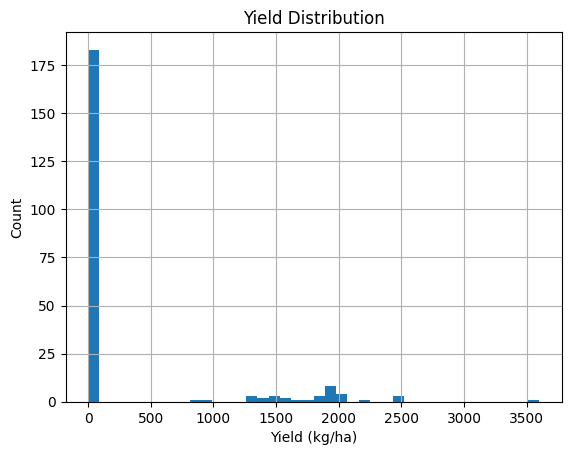

In [ ]:
df['YIELD'].hist(bins=40)
plt.title("Yield Distribution")
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Count")
plt.show()


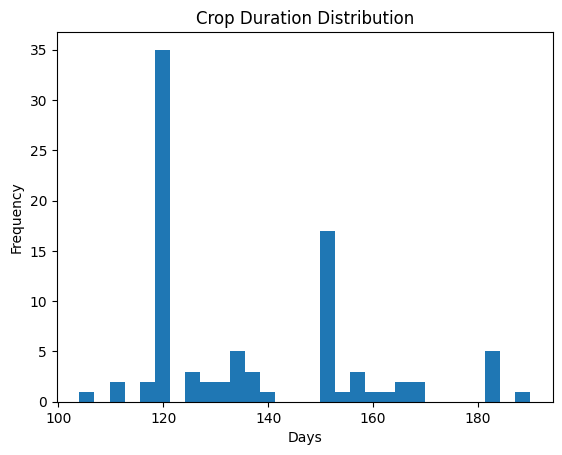

In [ ]:
import numpy as np

# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# Replace '0' (as string) with NaN in SOWING_DATE and HARVESTING_DATE columns
df['SOWING_DATE'] = df['SOWING_DATE'].replace('0', np.nan)
df['HARVESTING_DATE'] = df['HARVESTING_DATE'].replace('0', np.nan)

# Convert to datetime, coercing errors to NaT
df['SOWING_DATE'] = pd.to_datetime(df['SOWING_DATE'], format='%m/%d/%Y', errors='coerce')
df['HARVESTING_DATE'] = pd.to_datetime(df['HARVESTING_DATE'], format='%m/%d/%Y', errors='coerce')

df['duration_days'] = (df['HARVESTING_DATE'] - df['SOWING_DATE']).dt.days

df['duration_days'].plot(kind='hist', bins=30)
plt.title("Crop Duration Distribution")
plt.xlabel("Days")
plt.show()

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [72]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/sickle_toy_dataset.zip", 'r') as z:
    z.extractall("KFuji")
print("Extracted")


Extracted


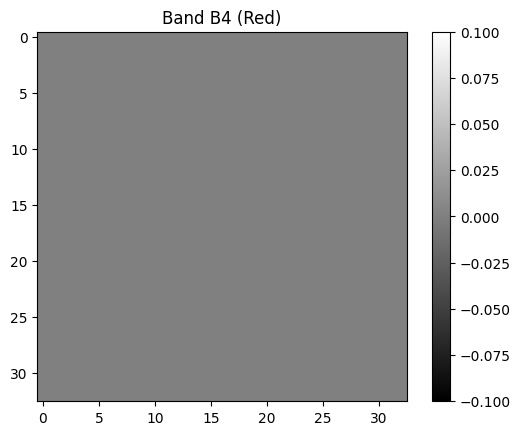

In [73]:
import rasterio
import matplotlib.pyplot as plt

path = "/content/KFuji/images/S2/tif/29/20191001T050701_20191001T050804_T44PKT/20191001T050701_20191001T050804_T44PKT.B4.tif"   # Red band

with rasterio.open(path) as src:
    img = src.read(1)

plt.imshow(img, cmap="gray")
plt.title("Band B4 (Red)")
plt.colorbar()
plt.show()


In [77]:
# SICKLE EDA and Analysis Notebook
# --------------------------------
# This script is a comprehensive, ready-to-run Jupyter/Colab-friendly Python
# notebook that performs the following on the SICKLE dataset (Sentinel-2 focus):
#  - Safe download of SICKLE_S2 (if you provide file or path)
#  - Extract and inspect folder structure and metadata
#  - Cloud masking using SCL
#  - Compute NDWI, EVI, SAVI maps
#  - Temporal analysis for multi-date samples
#  - PCA on multispectral bands
#  - Feature extraction for phenology prediction
#  - Crop yield regression using classical ML (RandomForest) and a small NN
#
# Notes:
#  - Run in Colab or local env. For Colab, mount your Drive and place SICKLE files
#    there or use the download block below to fetch the specific S2 zip from Zenodo.
#  - This script uses rasterio, numpy, matplotlib, pandas, scikit-learn, torch (optional)
#
# Sections are clearly marked. Run cells sequentially in a notebook environment.

# -------------------------------
# 0. Install required packages (Colab)
# -------------------------------
# Uncomment and run in Colab / fresh env if packages missing
#
!pip install rasterio matplotlib pandas scikit-learn tqdm geopandas pillow pyproj
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# -------------------------------
# 1. Imports
# -------------------------------
import os
import glob
import zipfile
from tqdm import tqdm
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import joblib

# Optional: torch for NN model
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

# -------------------------------
# 2. Paths and Utilities
# -------------------------------
ROOT = "/content/KFuji"  # change to your extracted path
S2_ROOT = os.path.join(ROOT, 'S2')
META_CSV = os.path.join(ROOT, 'sickle_dataset_tabular.csv')

# Utility: list samples
def list_samples(s2_root=S2_ROOT, max_samples=10):
    samples = sorted([d for d in glob.glob(os.path.join(s2_root, '*')) if os.path.isdir(d)])
    print(f"Found {len(samples)} samples. Showing up to {max_samples}:")
    for s in samples[:max_samples]:
        print('-', os.path.basename(s))
    return samples

# Utility: read a band (resample to target if needed)
def read_band(path, rescale_to=None):
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        profile = src.profile
    if rescale_to is not None and profile['transform'] is not None:
        # basic nearest resampling to match shape
        with rasterio.open(path) as src:
            arr = src.read(1, out_shape=rescale_to, resampling=Resampling.bilinear).astype('float32')
    return arr

# Utility: display RGB
def show_rgb(sample_dir, bands=('B4','B3','B2'), vmin=None, vmax=None, figsize=(8,8)):
    imgs = []
    for b in bands:
        p = glob.glob(os.path.join(sample_dir, f"*{b}*.tif"))
        if len(p)==0:
            raise FileNotFoundError(f"Band {b} not found in {sample_dir}")
        imgs.append(read_band(p[0]))
    rgb = np.dstack(imgs)
    rgb = rgb / (np.percentile(rgb, 98))
    rgb = np.clip(rgb, 0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(os.path.basename(sample_dir))

# -------------------------------
# 3. Cloud masking using SCL
# -------------------------------
# SCL codes of interest: 3 cloud shadow, 8-10 clouds, etc. We'll mask clouds and shadows.
CLOUD_CODES = [3, 8, 9, 10]  # shadow + clouds

def get_scl_mask(sample_dir, scl_name_pattern='*SCL*.tif'):
    files = glob.glob(os.path.join(sample_dir, scl_name_pattern))
    if not files:
        return None
    scl = read_band(files[0])
    mask = np.isin(scl, CLOUD_CODES)
    # True where cloud/shadow — we want to mask these
    return mask

# Example usage:
# mask = get_scl_mask('SICKLE_DATA/S2/sample_001')

# -------------------------------
# 4. Vegetation and Water Indices (NDWI, EVI, SAVI)
# -------------------------------
# NDWI = (G - NIR) / (G + NIR)
# EVI = 2.5 * (NIR - R) / (NIR + 6*R - 7.5*B + 1)
# SAVI = ((NIR - R) / (NIR + R + L)) * (1 + L)  (L typically 0.5)

def compute_indices(sample_dir, mask=None, bands_paths=None):
    # bands_paths: optional dict of band->path
    def find(b):
        if bands_paths and b in bands_paths:
            return bands_paths[b]
        p = glob.glob(os.path.join(sample_dir, f"*{b}*.tif"))
        if not p:
            raise FileNotFoundError(f"Band {b} not found in {sample_dir}")
        return p[0]

    R = read_band(find('B4'))
    G = read_band(find('B3'))
    B = read_band(find('B2'))
    NIR = read_band(find('B8'))

    # cast to float and avoid div by zero
    eps = 1e-6
    ndwi = (G - NIR) / (G + NIR + eps)
    evi = 2.5 * (NIR - R) / (NIR + 6*R - 7.5*B + 1 + eps)
    L = 0.5
    savi = ((NIR - R) / (NIR + R + L + eps)) * (1 + L)

    if mask is not None:
        ndwi = np.where(mask, np.nan, ndwi)
        evi = np.where(mask, np.nan, evi)
        savi = np.where(mask, np.nan, savi)

    return {
        'NDWI': ndwi,
        'EVI': evi,
        'SAVI': savi
    }

# Visualization helper
def plot_index(idx_arr, title='NDVI', cmap='RdYlGn', vmin=None, vmax=None):
    plt.figure(figsize=(6,6))
    plt.imshow(idx_arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.axis('off')

# -------------------------------
# 5. Temporal analysis (multi-date per sample)
# -------------------------------
# SICKLE provides multiple dates per sample. We'll create time series for indices.

def sample_timeseries(sample_dir, dates_list=None, scl_pattern='*SCL*.tif'):
    # This helper assumes the sample_dir contains per-date subdirectories or filenames with dates
    # Two common layouts:
    # 1) sample_dir/date_YYYYMMDD/B4.tif  (subdir per date)
    # 2) sample_dir/*_YYYYMMDD_B4.tif     (files with date in name)

    # Try layout 1 first
    subdirs = sorted([d for d in glob.glob(os.path.join(sample_dir,'*')) if os.path.isdir(d)])
    time_points = []
    if subdirs:
        for d in subdirs:
            # infer date from folder name if possible
            name = os.path.basename(d)
            time_points.append((name, d))
    else:
        # fallback: search for all B4 files and parse date from filename
        files = sorted(glob.glob(os.path.join(sample_dir, '*B4*.tif')))
        for f in files:
            name = os.path.basename(f)
            # try to extract YYYYMMDD pattern
            import re
            m = re.search(r"(19|20)\d{6}", name)
            date_str = m.group(0) if m else name
            time_points.append((date_str, os.path.dirname(f)))

    # compute indices per time point
    records = []
    for date_str, dpath in time_points:
        try:
            mask = get_scl_mask(dpath)
            inds = compute_indices(dpath, mask=mask)
            # take mean of indices over valid pixels
            rec = {
                'date': date_str,
                'NDWI': np.nanmean(inds['NDWI']),
                'EVI': np.nanmean(inds['EVI']),
                'SAVI': np.nanmean(inds['SAVI'])
            }
            records.append(rec)
        except Exception as e:
            print('Skipping', date_str, 'error:', e)
    df_ts = pd.DataFrame(records)
    # try parse date column
    try:
        df_ts['date'] = pd.to_datetime(df_ts['date'], format='%Y%m%d')
    except Exception:
        df_ts['date'] = pd.to_datetime(df_ts['date'], errors='coerce')
    df_ts = df_ts.sort_values('date')
    return df_ts

# Plot time series
def plot_timeseries(df_ts, title='Indices over time'):
    plt.figure(figsize=(10,4))
    plt.plot(df_ts['date'], df_ts['NDWI'], label='NDWI')
    plt.plot(df_ts['date'], df_ts['EVI'], label='EVI')
    plt.plot(df_ts['date'], df_ts['SAVI'], label='SAVI')
    plt.legend()
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Index value')
    plt.grid(True)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()

# -------------------------------
# 6. PCA on multispectral bands
# -------------------------------

def stack_bands(sample_dir, band_list=None):
    if band_list is None:
        band_list = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
    arrays = []
    for b in band_list:
        p = glob.glob(os.path.join(sample_dir, f"*{b}*.tif"))
        if not p:
            raise FileNotFoundError(f"Band {b} not found in {sample_dir}")
        arrays.append(read_band(p[0]))
    stack = np.stack(arrays, axis=-1)
    return stack, band_list

def run_pca_on_sample(sample_dir, n_components=3):
    stack, band_list = stack_bands(sample_dir)
    h,w,c = stack.shape
    # reshape and drop nan or invalid
    X = stack.reshape(-1, c)
    # normalize per band
    X = np.nan_to_num(X)
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-6)
    pca = PCA(n_components=n_components)
    comps = pca.fit_transform(X)
    comps_img = comps.reshape(h,w,n_components)
    return pca, comps_img

# -------------------------------
# 7. Feature extraction for phenology prediction
# -------------------------------
# We will compute features per sample: mean/std of indices, phenology date differences from metadata,
# temporal curve features (peak, time-to-peak), PCA components stats, and optionally texture features.

from scipy.signal import find_peaks

def extract_sample_features(sample_dir, metadata_row=None):
    # metadata_row: pandas Series with sowing/harvest dates and yield etc.
    features = {}
    # 1) static band stats
    stack, bands = stack_bands(sample_dir)
    features['band_mean'] = np.nanmean(stack)
    features['band_std'] = np.nanstd(stack)
    # 2) compute indices on a median date or aggregate across available dates
    # If sample_dir contains multiple dates, compute temporal metrics
    df_ts = sample_timeseries(sample_dir)
    if not df_ts.empty:
        # basic stats
        features['NDWI_mean'] = df_ts['NDWI'].mean()
        features['NDWI_std'] = df_ts['NDWI'].std()
        features['EVI_mean'] = df_ts['EVI'].mean()
        features['EVI_std'] = df_ts['EVI'].std()
        # peak detection on EVI (proxy for greenup)
        try:
            arr = df_ts['EVI'].fillna(method='ffill').values
            peaks, _ = find_peaks(arr)
            features['EVI_peak_count'] = len(peaks)
            if len(peaks)>0:
                features['EVI_peak_val'] = arr[peaks].max()
        except Exception:
            features['EVI_peak_count'] = 0
    else:
        features.update({k:np.nan for k in ['NDWI_mean','NDWI_std','EVI_mean','EVI_std','EVI_peak_count','EVI_peak_val']})

    # 3) PCA based features
    try:
        pca, comps_img = run_pca_on_sample(sample_dir, n_components=3)
        features['pca_explained_0'] = pca.explained_variance_ratio_[0]
        features['pca_explained_1'] = pca.explained_variance_ratio_[1]
        features['pca_mean_0'] = np.nanmean(comps_img[...,0])
    except Exception:
        features.update({k:np.nan for k in ['pca_explained_0','pca_explained_1','pca_mean_0']})

    # 4) metadata-derived features
    if metadata_row is not None:
        # e.g., sowing to harvest duration
        try:
            s = pd.to_datetime(metadata_row['sowing_date'])
            h = pd.to_datetime(metadata_row['harvest_date'])
            features['duration_days'] = (h - s).days
        except Exception:
            features['duration_days'] = np.nan
        # yield
        if 'yield' in metadata_row.index:
            features['yield'] = metadata_row['yield']
    return features

# -------------------------------
# 8. Build dataset for regression (loop through samples)
# -------------------------------

def build_feature_table(s2_root=S2_ROOT, meta_csv=META_CSV):
    meta = pd.read_csv(meta_csv)
    rows = []
    samples = list_samples(s2_root, max_samples=10000)
    for s in tqdm(samples):
        sid = os.path.basename(s)
        # match metadata row by sample id column name (adjust as necessary)
        md = meta[meta['sample_id']==sid] if 'sample_id' in meta.columns else None
        md_row = md.iloc[0] if md is not None and not md.empty else None
        try:
            feats = extract_sample_features(s, md_row)
            feats['sample_id'] = sid
            if md_row is not None and 'yield' in md_row.index:
                feats['yield'] = md_row['yield']
            rows.append(feats)
        except Exception as e:
            print('Error processing', sid, e)
    df = pd.DataFrame(rows)
    return df

# -------------------------------
# 9. Crop yield regression (RandomForest)
# -------------------------------

def train_random_forest(df_features, target='yield'):
    df = df_features.dropna(subset=[target])
    X = df.drop(columns=['sample_id', target], errors='ignore').select_dtypes(include=[np.number]).fillna(0)
    y = df[target].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)
    ypred = rf.predict(X_test)
    print('R2:', r2_score(y_test, ypred))
    print('RMSE:', np.sqrt(mean_squared_error(y_test, ypred)))
    return rf, X_test, y_test, ypred

# -------------------------------
# 10. Optional: Simple NN Regression (torch)
# -------------------------------
if TORCH_AVAILABLE:
    class SimpleRegressor(nn.Module):
        def __init__(self, n_in):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_in, 128),
                nn.ReLU(),
                nn.Linear(128,64),
                nn.ReLU(),
                nn.Linear(64,1)
            )
        def forward(self,x):
            return self.net(x)

    def train_nn(X_train, y_train, X_val, y_val, epochs=50, lr=1e-3):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = SimpleRegressor(X_train.shape[1]).to(device)
        opt = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        Xtr = torch.tensor(X_train.values, dtype=torch.float32).to(device)
        ytr = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32).to(device)
        Xval = torch.tensor(X_val.values, dtype=torch.float32).to(device)
        yval = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32).to(device)
        for ep in range(epochs):
            model.train()
            opt.zero_grad()
            out = model(Xtr)
            loss = loss_fn(out, ytr)
            loss.backward()
            opt.step()
            if ep%10==0:
                model.eval()
                with torch.no_grad():
                    val_loss = loss_fn(model(Xval), yval).item()
                print(f"Epoch {ep} train_loss={loss.item():.4f} val_loss={val_loss:.4f}")
        return model

# -------------------------------
# 11. Save / Load models
# -------------------------------
def save_model(model, path='rf_model.joblib'):
    joblib.dump(model, path)

# -------------------------------
# 12. Example run sequence (put in notebook cells)
# -------------------------------
if __name__ == '__main__':
    print('This file is intended as a notebook. Import functions or run sections interactively.')
    # Example minimal run:
    # samples = list_samples()
    # show_rgb(samples[0])
    # mask = get_scl_mask(samples[0])
    # inds = compute_indices(samples[0], mask=mask)
    # plot_index(inds['NDWI'], 'NDWI')
    pass


Looking in indexes: https://download.pytorch.org/whl/cpu
This file is intended as a notebook. Import functions or run sections interactively.


Found 24 samples. Showing up to 10:
- 20180908T045649_20180908T045649_T44PLS
- 20180913T045651_20180913T045651_T44PLS
- 20180918T045649_20180918T045649_T44PLS
- 20180928T045649_20180928T045649_T44PLS
- 20181003T045651_20181003T045651_T44PLS
- 20181028T045909_20181028T045909_T44PLS
- 20181107T050009_20181107T050009_T44PLS
- 20181112T050031_20181112T050031_T44PLS
- 20181127T050129_20181127T050129_T44PLS
- 20181217T050219_20181217T050336_T44PLS


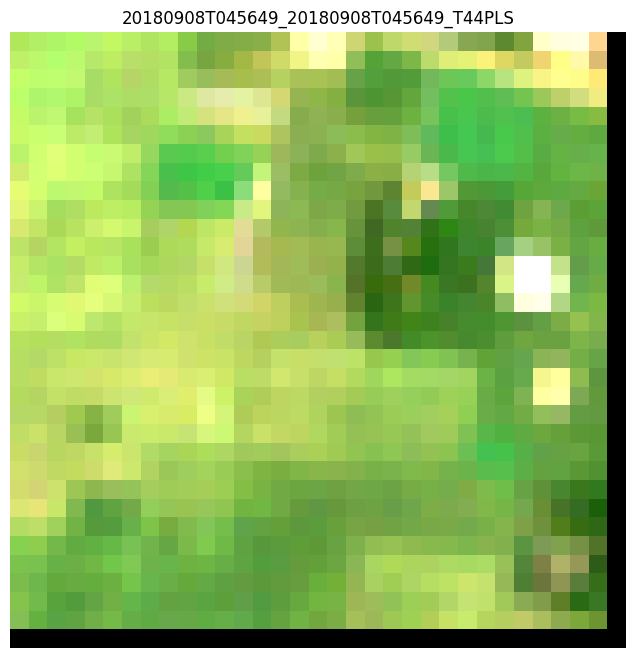

In [84]:
samples = list_samples("/content/KFuji/images/S2/tif/1003/")

sample = samples[0]
show_rgb(sample)


Text(0.5, 1.0, 'RGB Composite')

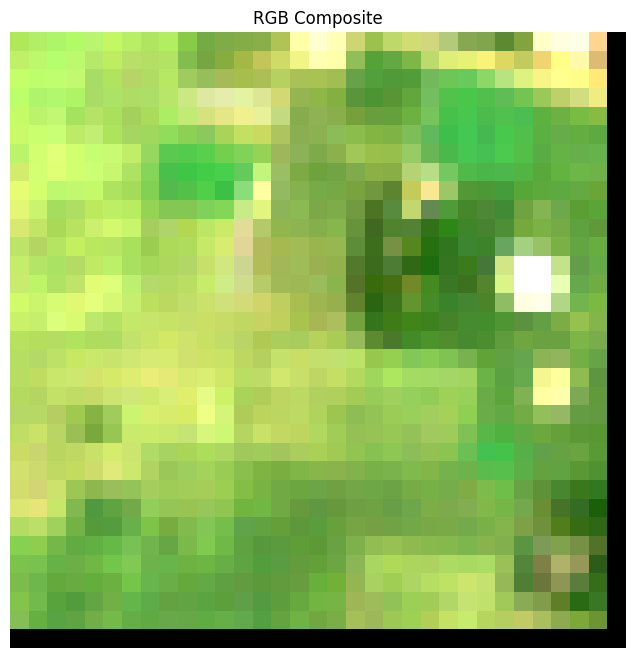

In [85]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

folder = "/content/KFuji/images/S2/tif/1003/20180908T045649_20180908T045649_T44PLS"

# B4 = Red, B3 = Green, B2 = Blue
with rasterio.open("/content/KFuji/images/S2/tif/1003/20180908T045649_20180908T045649_T44PLS/20180908T045649_20180908T045649_T44PLS.B4.tif") as r:
    R = r.read(1)
with rasterio.open("/content/KFuji/images/S2/tif/1003/20180908T045649_20180908T045649_T44PLS/20180908T045649_20180908T045649_T44PLS.B3.tif") as g:
    G = g.read(1)
with rasterio.open("/content/KFuji/images/S2/tif/1003/20180908T045649_20180908T045649_T44PLS/20180908T045649_20180908T045649_T44PLS.B2.tif") as b:
    B = b.read(1)

rgb = np.dstack([R, G, B]).astype(float)

# Stretch colors
rgb = rgb / np.percentile(rgb, 98)
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.axis("off")
plt.title("RGB Composite")
